In [1]:
import pandas as pd
from rsim import load_yield_data
from rsim import YieldCurveSimulator as Simulator

Loading historical data

In [2]:
yield_data = load_yield_data("FRB_H15.xlsx", min_date='2000-01-01', scale=0.01)
yield_data.head(5)

Initial data shape: (872, 11)
Columns: ['Time Period', 0, 3, 6, 12, 24, 36, 60, 84, 120, 360]
Using 'Time Period' as date column
Final column names (maturities in months): [0, 3, 6, 12, 24, 36, 60, 84, 120, 360]
Data validation successful!
Final data shape: (311, 10)
Date range: 2000-01-01 00:00:00 to 2025-11-01 00:00:00
Maturities: [0, 3, 6, 12, 24, 36, 60, 84, 120, 360] months


,0,3,6,12,24,36,60,84,120,360
Date,,,,,,,,,,
2000-01-01,0.0545,0.0550,0.0576,0.0612,0.0644,0.0649,0.0658,0.0670,0.0666,0.0663
2000-02-01,0.0573,0.0573,0.0600,0.0622,0.0661,0.0665,0.0668,0.0672,0.0652,0.0623
2000-03-01,0.0585,0.0586,0.0611,0.0622,0.0653,0.0653,0.0650,0.0651,0.0626,0.0605
2000-04-01,0.0602,0.0582,0.0607,0.0615,0.0640,0.0636,0.0626,0.0627,0.0599,0.0585
2000-05-01,0.0627,0.0599,0.0639,0.0633,0.0681,0.0677,0.0669,0.0669,0.0644,0.0615


PCA Decomposition of Yield Curve
===============
3 factors (level, slope and curvature) can explain majority of variability in the historical yield curve.  
Using 3 factors will significantly reduce the dimension of simulation without much loss of accuracy.

In [3]:
# pca dimension reduction
n_factors = 3
simulator = Simulator(n_factors=3)
simulator.fit(yield_data)

print(simulator.get_model_summary())

{'n_factors': 3, 'n_maturities': 10, 'n_observations': 311, 'explained_variance_ratio': array([0.9203, 0.0692, 0.0084]), 'cumulative_explained_variance': 0.9979}


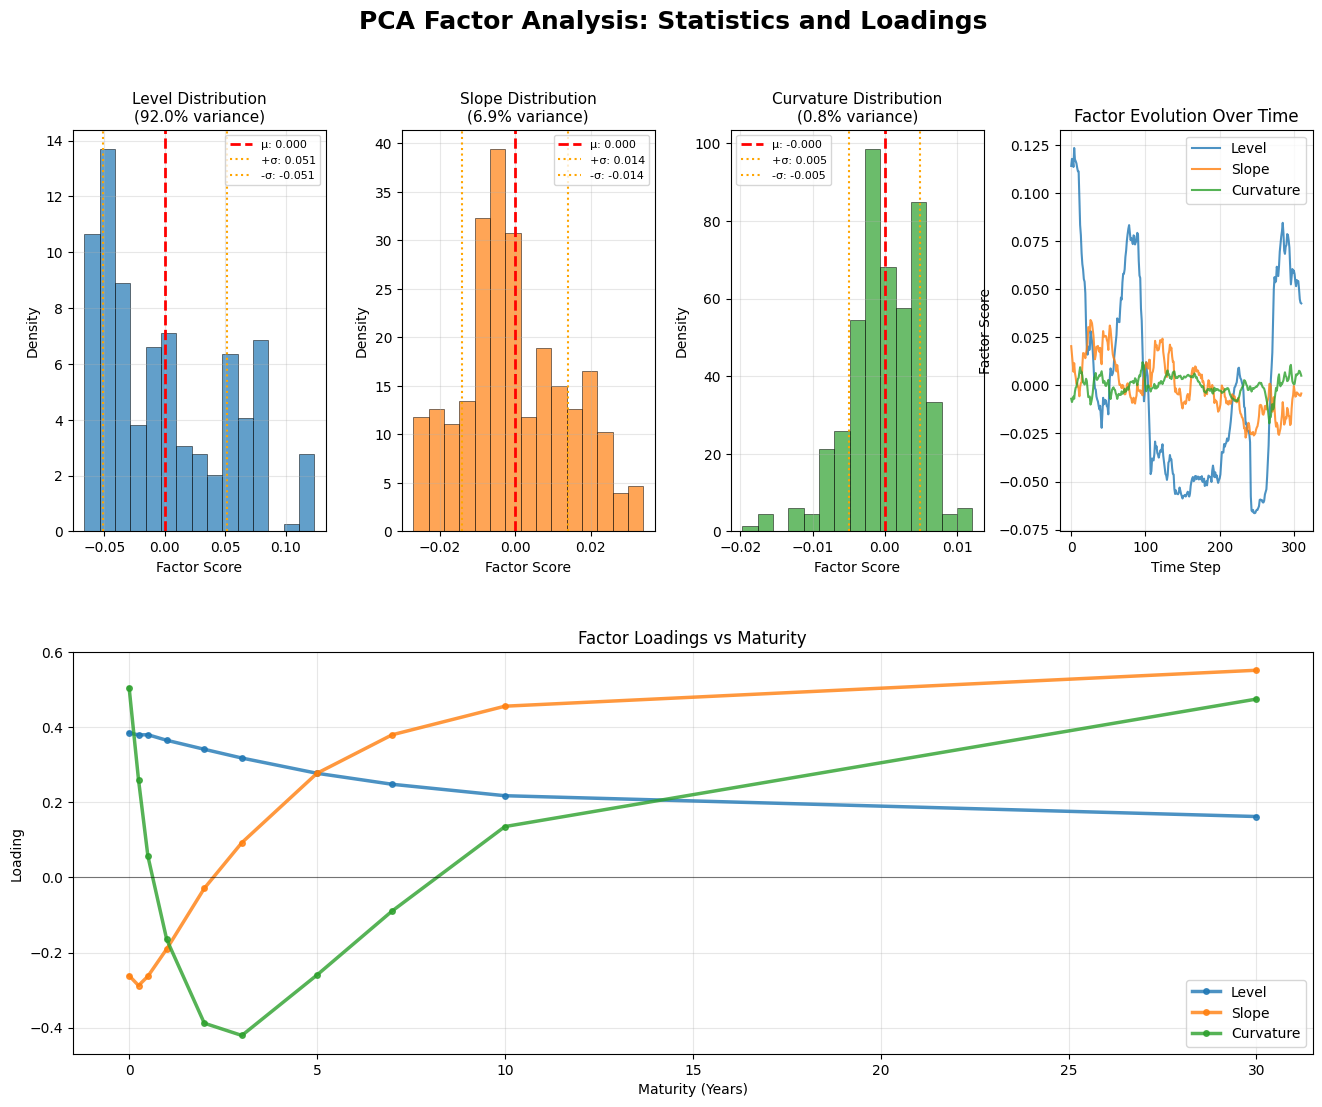

In [4]:
simulator.plot_factor_analysis()

Yield Curve Simulation
============
Simulating 1000 paths with 120 steps (months)

In [5]:
# variables for simulated paths
n_paths = 1000
n_steps = 120
sim_start_index = -1 # starting point of simulated paths (from the end of historical curves)
sim_start_date = yield_data.index[sim_start_index] 

In [6]:
X_sim, Y_sim = simulator.simulate(n_paths=n_paths, n_steps=n_steps, sim_start_index=sim_start_index)

Analysis of simulated yield curves
=======

Observing timeseries of simulated yield for various maturities, the mean path and fluctuations around the mean path

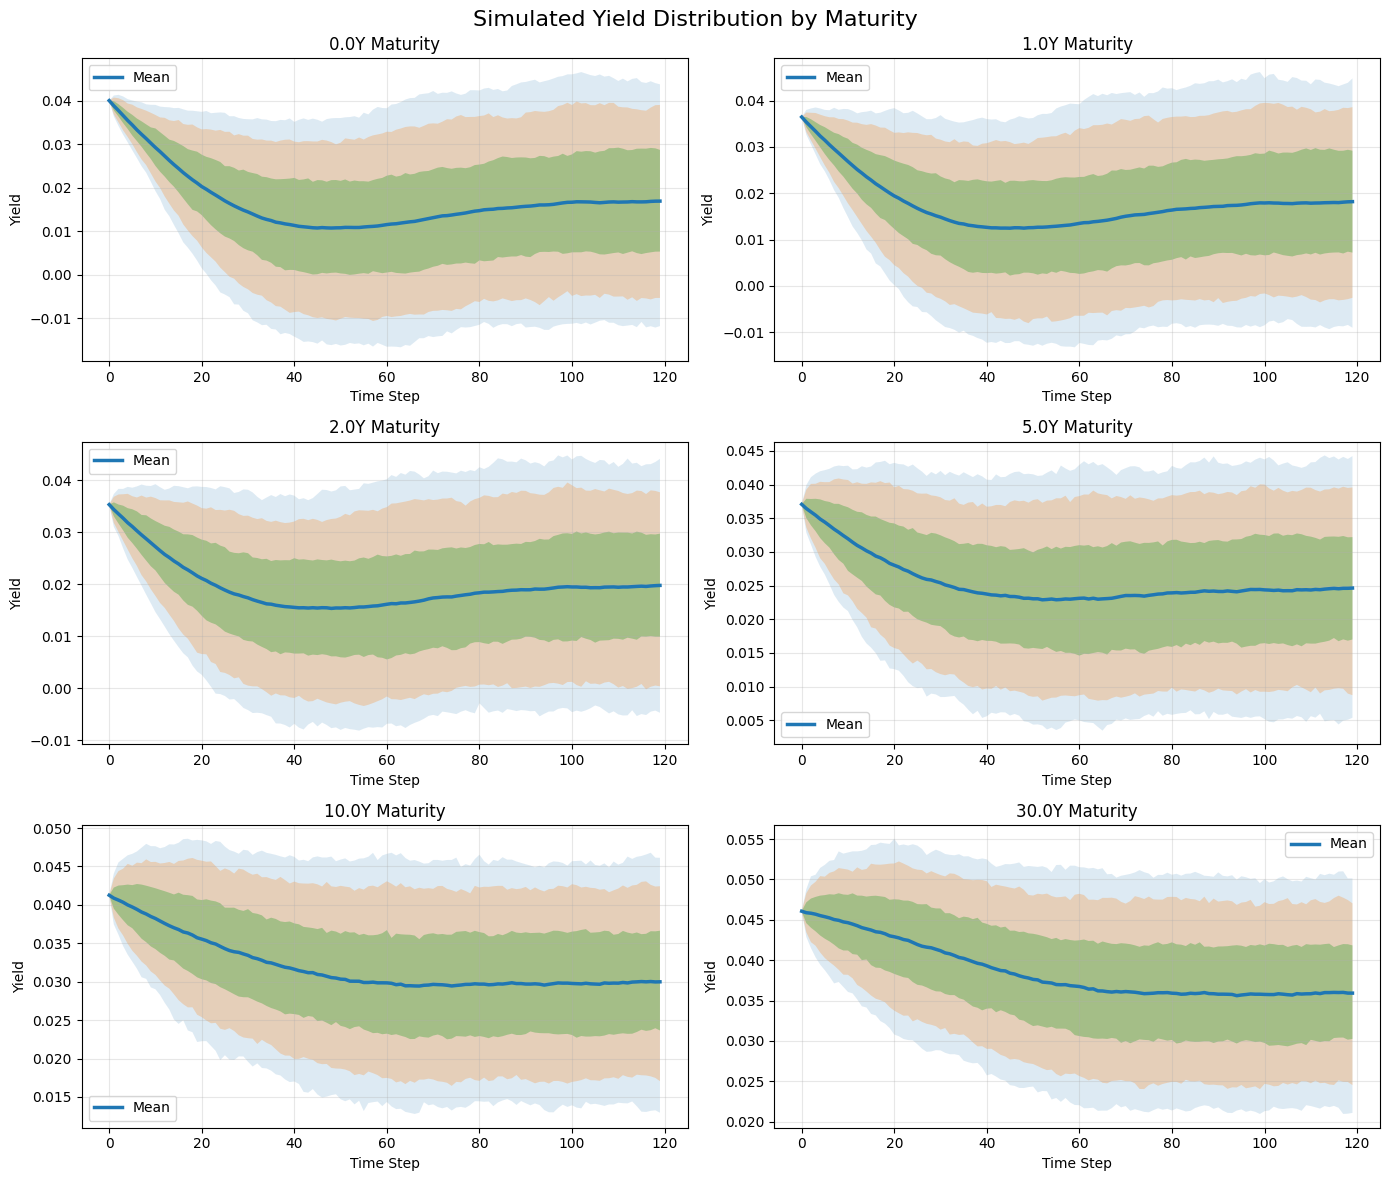

In [7]:
sample_maturities = [0, 12, 24, 60, 120, 360]
simulator.plot_yield_timeseries(Y_sim, sample_maturities, fan_chart=True)

Observing yield distribution of sample maturities in historical data vs simulated curves.  
Shorter maturities showing skewness in historical data that is not present in simulated curves, which has Gaussian distribution.

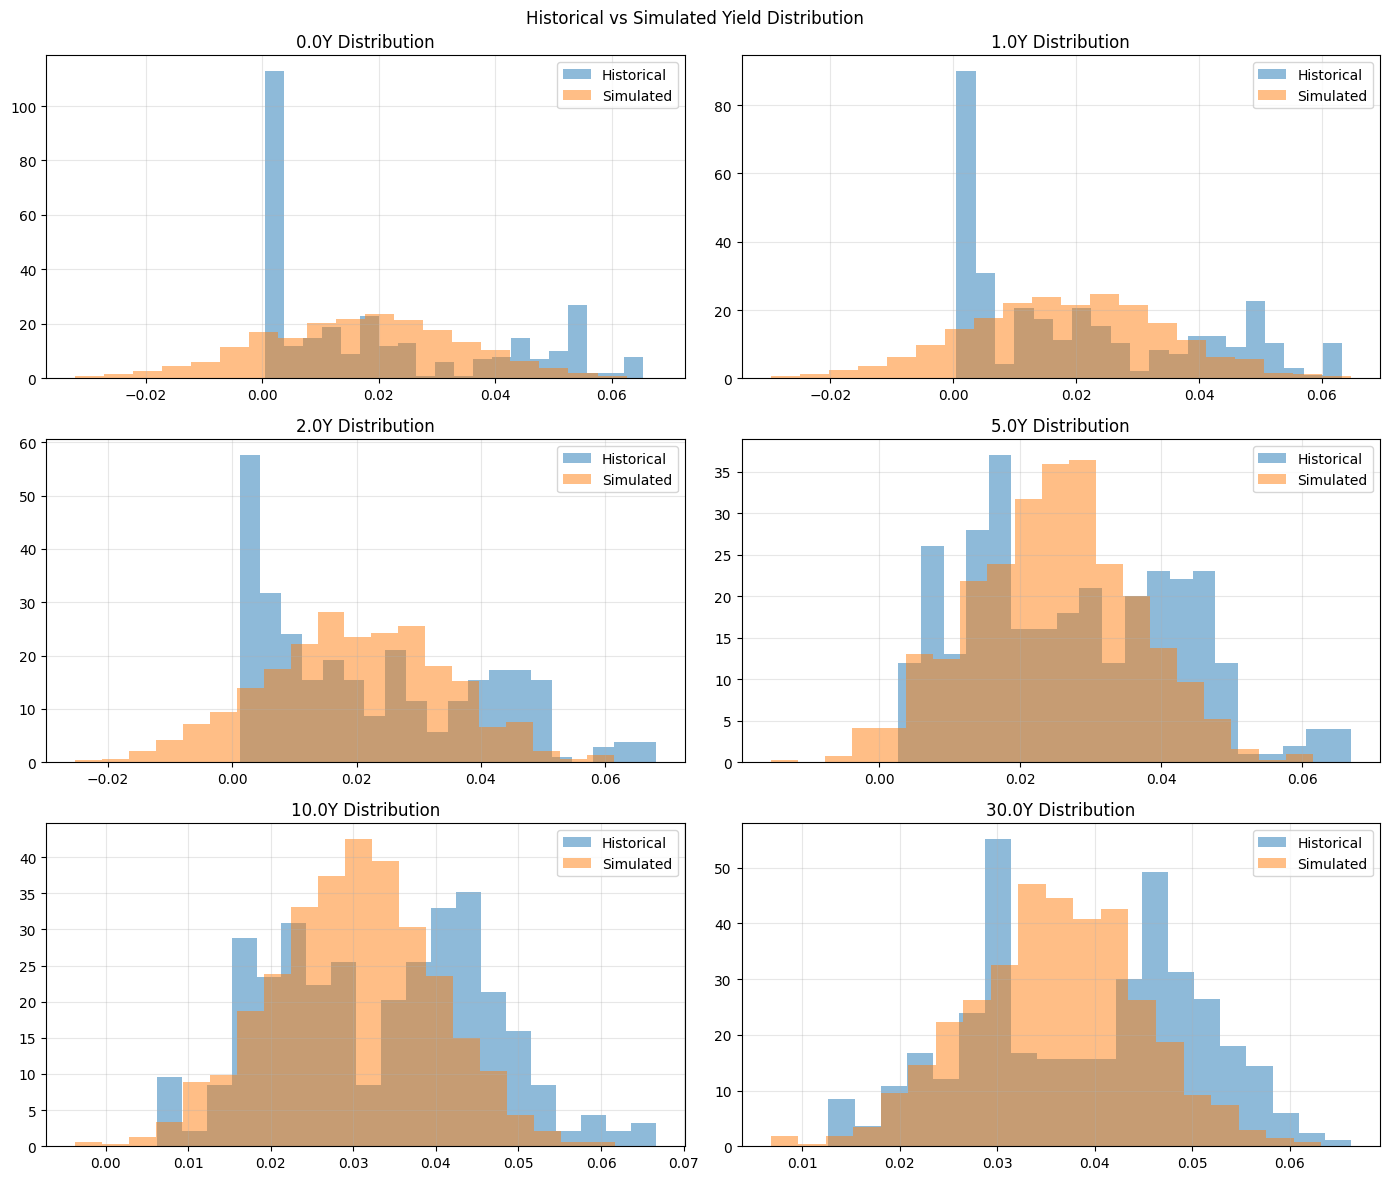

In [8]:
simulator.plot_yield_distribution_comparison(Y_sim, sample_maturities)

Observing shock distribution (change in yield) of sample maturities in historical data vs simulated curves.  
Similar to previous plots, the shock distribution for longer maturities align better between historical and simulated curves. Shorter maturities showing **jump-diffusion** process in historical data that is not captured in simulated curves (following Gaussian distribution).

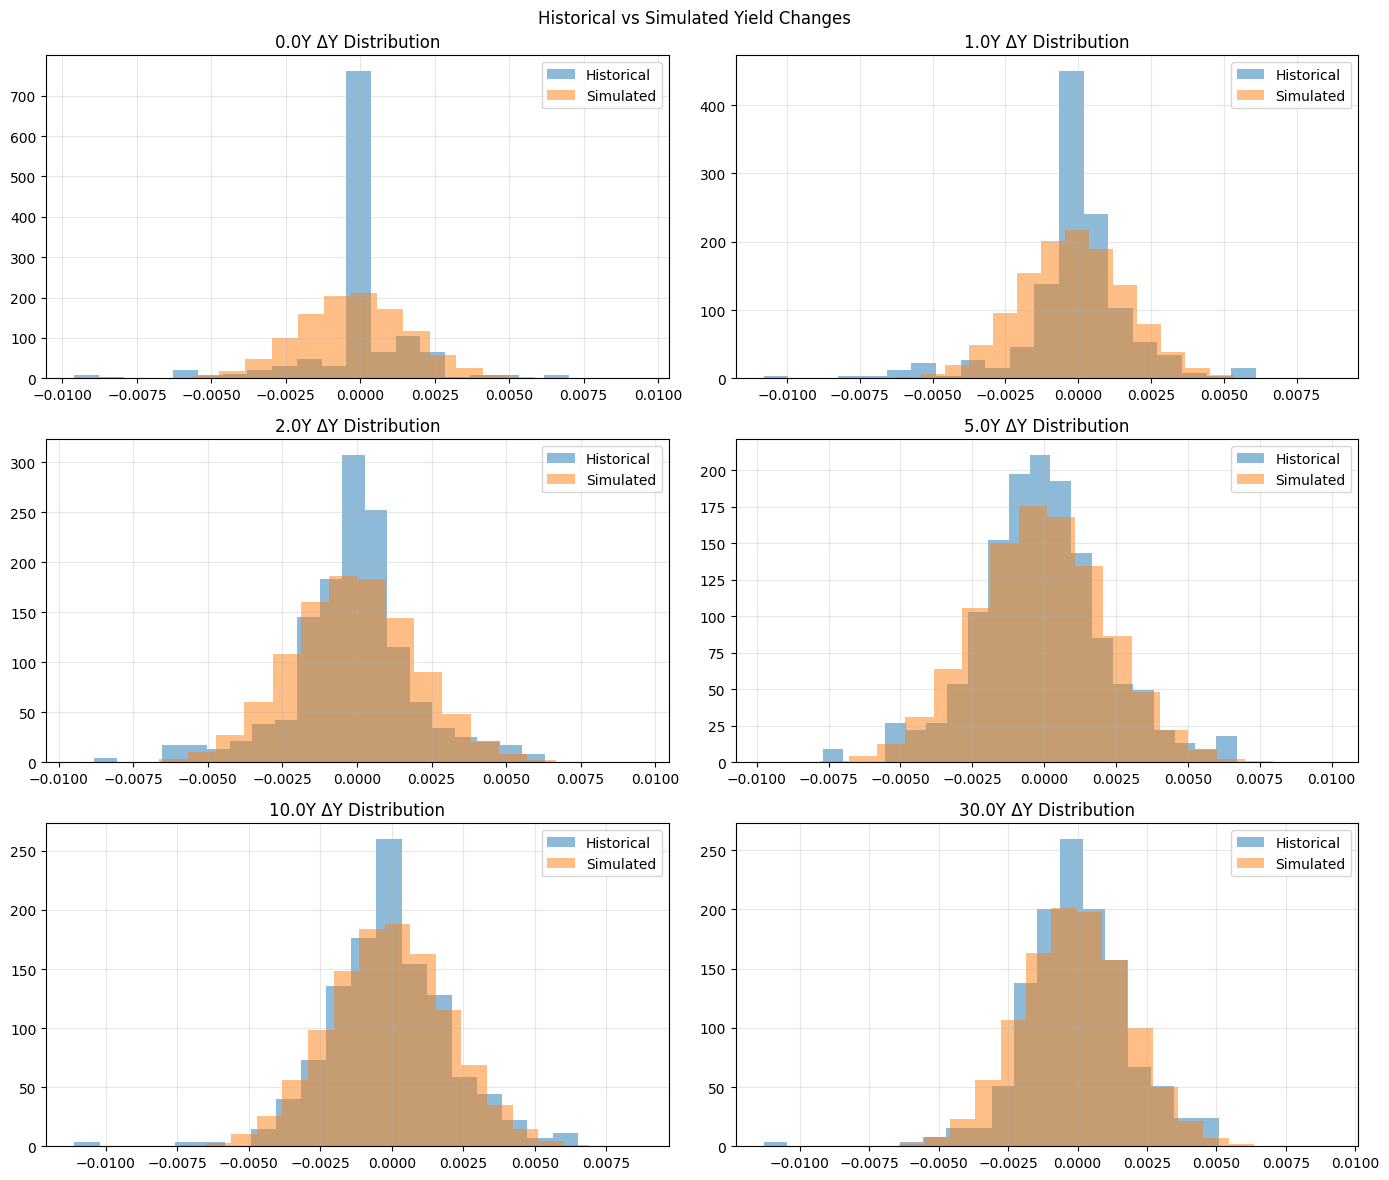

In [9]:
simulator.plot_delta_y_distribution(Y_sim, sample_maturities)

Comparison of slope and curvature distribution between historical and simulated paths

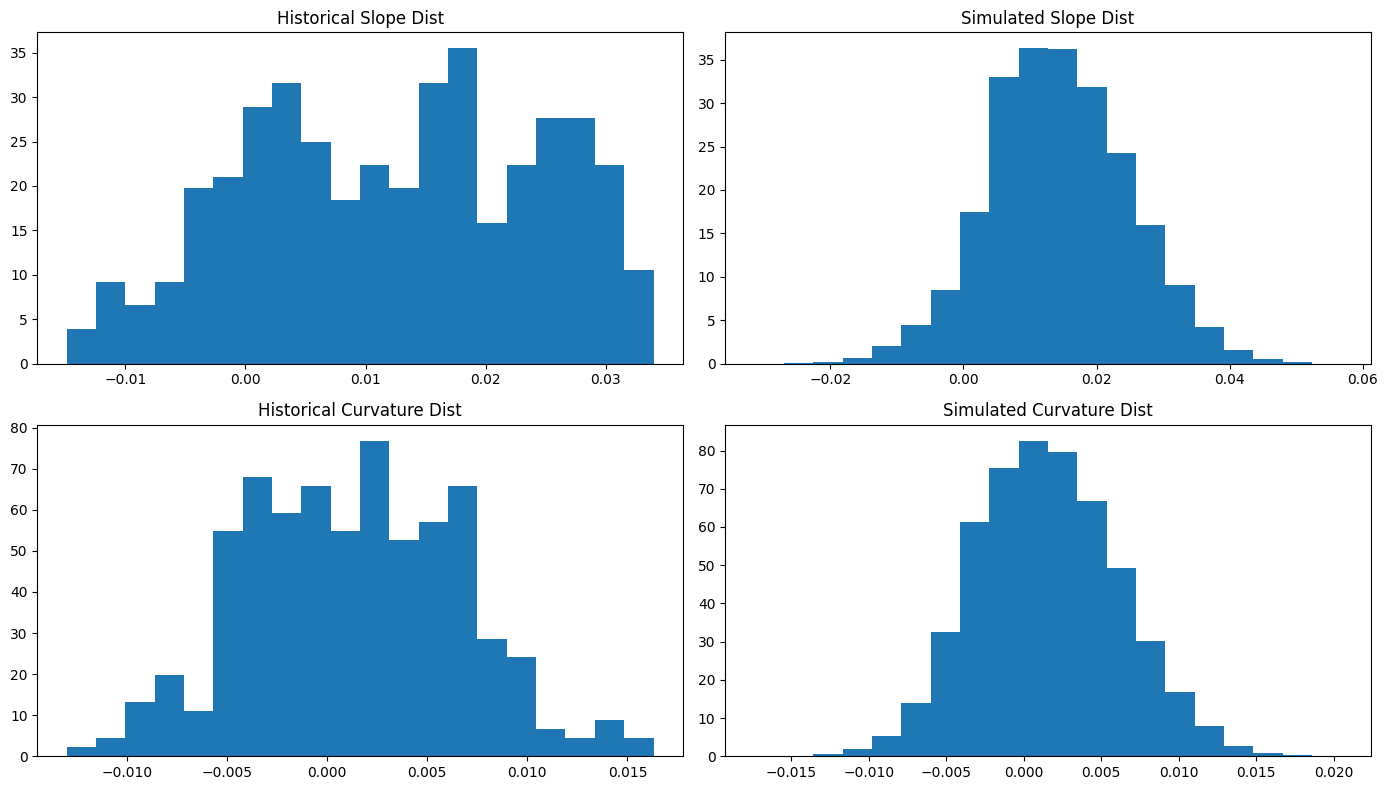

In [10]:
simulator.plot_slope_curvature_diagnostics(Y_sim, 12, 60, 120)

Correlation of maturities in historical and simulated paths

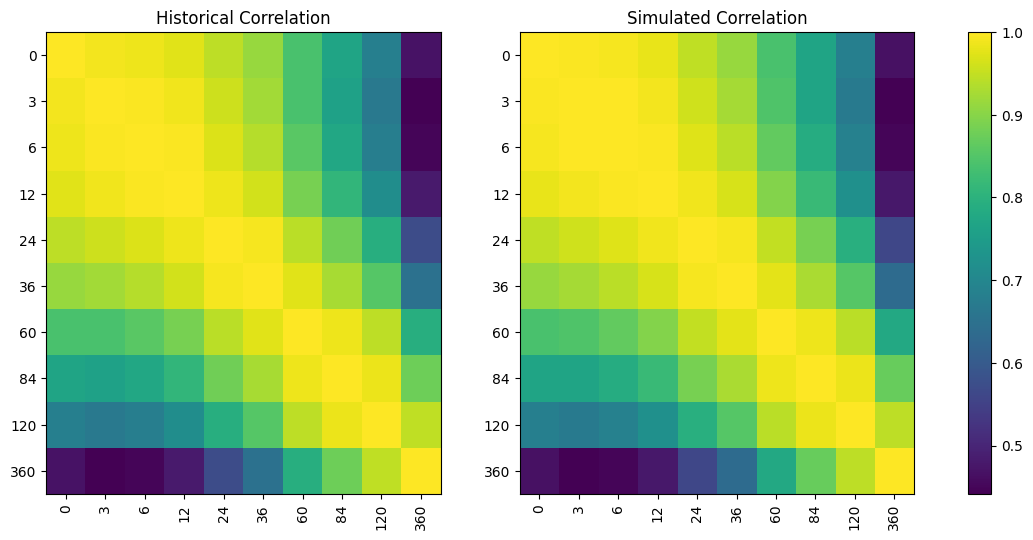

In [11]:
simulator.plot_correlation_comparison(Y_sim)

Concluding Remarks
=============
The PCA + VAR(1) model can produce a reasonable set of simulated yield curves for risk modelling. However, the model exhibits a few shortcomings that should be considered. We summarize these shortcomings here. Depending on the usage, a more sophisticated model for simulating yield curves may be necessary.   

1. The **level** factor goes through more negative values in simulations compared to historical timeseries. Due to this behaviour, Simulated curves, in particular for shorter maturities, would occassionally hit negative rates, while historical curves do not exhibit such behaviour.
2. The changes to historical short rates are often sudden jumps, following a jump-diffusion process, rather than a smooth gradual change in simulated curves. As a result, some of the statistical properties of simulated short rates do not align well with historical trends.

Both these behaviours in simulated paths are due to VAR model construction:
1. Shocks in VAR model are symmetric, hence creating the same probability of level going upward as downward.
2. VAR model, by construction, produces rather smooth curves and it's unable to properly replicate sudden jumps observed in short rates.